In [17]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 50)

In [18]:
print("="*80)
print("NOTEBOOK 2: K-MEANS RISK → PREMIUM MODELING")
print("="*80)

# 1) Raw Kaggle train file
df_raw = pd.read_csv("../data/train.csv")
print(f"Raw rows: {len(df_raw):,}")

# 2) K-Means risk classifications (Mrudul's output)
df_kmeans = pd.read_csv("../data/data_with_kmeans_risk_classes.csv")
print(f"KMeans rows: {len(df_kmeans):,}")

# Sanity check
assert len(df_raw) == len(df_kmeans), "Row counts do not match!"

# Work on a copy
df = df_raw.copy()

# Attach KMeans risk class (0/1/2)
df["KMeans_Risk_Class"] = df_kmeans["Risk_Class"]

# Optional: if Risk_Label column exists, attach it
if "Risk_Label" in df_kmeans.columns:
    df["KMeans_Risk_Label"] = df_kmeans["Risk_Label"]
else:
    label_map = {0: "Low Risk", 1: "Medium Risk", 2: "High Risk"}
    df["KMeans_Risk_Label"] = df["KMeans_Risk_Class"].map(label_map)

print("\nK-Means Risk Class distribution:")
print(df["KMeans_Risk_Class"].value_counts().sort_index())
print("\nK-Means Risk Class % distribution:")
print((df["KMeans_Risk_Class"].value_counts(normalize=True)
       .sort_index() * 100).round(2))

NOTEBOOK 2: K-MEANS RISK → PREMIUM MODELING
Raw rows: 1,200,000
KMeans rows: 1,200,000

K-Means Risk Class distribution:
KMeans_Risk_Class
0    543150
1    486930
2    169920
Name: count, dtype: int64

K-Means Risk Class % distribution:
KMeans_Risk_Class
0    45.26
1    40.58
2    14.16
Name: proportion, dtype: float64


In [19]:
print("\n[Step 2] Handling missing values...")

numeric_cols = [
    "Age",
    "Annual Income",
    "Health Score",
    "Credit Score",
    "Previous Claims",
    "Vehicle Age",
    "Number of Dependents",
]

for col in numeric_cols:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

if "Smoking Status" in df.columns:
    df["Smoking Status"].fillna(df["Smoking Status"].mode()[0], inplace=True)

if "Exercise Frequency" in df.columns:
    df["Exercise Frequency"].fillna(df["Exercise Frequency"].mode()[0], inplace=True)

print("Missing values handled ✓")


[Step 2] Handling missing values...


/var/folders/l_/2vlw7m7d75n2_mk6fws8dmgr0000gn/T/ipykernel_59977/1184035338.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/var/folders/l_/2vlw7m7d75n2_mk6fws8dmgr0000gn/T/ipykernel_59977/1184035338.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

Missing values handled ✓


/var/folders/l_/2vlw7m7d75n2_mk6fws8dmgr0000gn/T/ipykernel_59977/1184035338.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Exercise Frequency"].fillna(df["Exercise Frequency"].mode()[0], inplace=True)


In [20]:
inc_p25, inc_p50, inc_p75 = df['Annual Income'].quantile([0.25, 0.5, 0.75])
health_p25, health_p50, health_p75 = df['Health Score'].quantile([0.25, 0.5, 0.75])

print("Income thresholds:", inc_p25, inc_p50, inc_p75)
print("Health thresholds:", health_p25, health_p50, health_p75)

Income thresholds: 8646.0 23911.0 43936.0
Health thresholds: 16.554571709744692 24.57864816412784 33.772890114798805


In [21]:
def calculate_premium_from_risk(row, 
                                  inc_p25=inc_p25, inc_p75=inc_p75, 
                                  health_p25=health_p25, health_p75=health_p75,
                                  risk_class_col="Risk_Class"):
    """
    Rule-Based Premium Model (Aligned with Enhanced Manual Risk Index v2)
    but allows selecting which risk class column to use:
    - "Risk_Class" (manual)
    - "KMeans_Risk_Class" (unsupervised)
    """

    base = 500
    
    # AGE
    age = row["Age"]
    if age < 30:
        age_factor = 0.90
    elif age < 50:
        age_factor = 1.00
    else:
        age_factor = 1.10
        
    # INCOME (adaptive)
    income = row["Annual Income"]
    if income > inc_p75:
        income_factor = 0.90
    elif income > inc_p25:
        income_factor = 1.00
    else:
        income_factor = 1.10
        
    # SMOKING
    smoking_factor = 1.30 if row["Smoking Status"] == "Yes" else 1.00

    # HEALTH (adaptive)
    health = row["Health Score"]
    if health > health_p75:
        health_factor = 0.90
    elif health > health_p25:
        health_factor = 1.00
    else:
        health_factor = 1.10
        
    # CREDIT
    credit = row["Credit Score"]
    if credit > 650:
        credit_factor = 0.90
    elif credit > 400:
        credit_factor = 1.00
    else:
        credit_factor = 1.20
        
    # CLAIMS
    claims = row["Previous Claims"]
    if claims == 0:
        claims_factor = 0.90
    elif claims <= 2:
        claims_factor = 1.05
    else:
        claims_factor = 1.25
        
    # VEHICLE AGE
    vehicle_age = row["Vehicle Age"]
    if vehicle_age <= 5:
        vehicle_factor = 0.95
    elif vehicle_age <= 10:
        vehicle_factor = 1.00
    else:
        vehicle_factor = 1.10
        
    # EXERCISE
    exercise = row["Exercise Frequency"]
    exercise_factor = 1.05 if exercise in ["Monthly", "Rarely"] else 1.00
        
    # DEPENDENTS
    dependents = row["Number of Dependents"]
    dependents_factor = 1.05 if dependents > 3 else 1.00
        
    # FINAL MULTIPLIER
    risk_class = row[risk_class_col]
    tier_factor = {0: 0.90, 1: 1.00, 2: 1.25}[risk_class]

    # FINAL PREMIUM
    premium = (base 
               * age_factor
               * income_factor
               * smoking_factor
               * health_factor
               * credit_factor
               * claims_factor
               * vehicle_factor
               * exercise_factor
               * dependents_factor
               * tier_factor
              )
    
    return premium

In [22]:
print("[Fix] Converting numeric columns from strings → floats...")

numeric_cols = [
    "Age",
    "Annual Income",
    "Health Score",
    "Credit Score",
    "Previous Claims",
    "Vehicle Age",
    "Number of Dependents"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["KMeans_Risk_Class"] = pd.to_numeric(df["KMeans_Risk_Class"], errors="coerce").astype(int)

print(df[numeric_cols].dtypes)
print("\nNumeric conversion complete ✓")

[Fix] Converting numeric columns from strings → floats...
Age                     float64
Annual Income           float64
Health Score            float64
Credit Score            float64
Previous Claims         float64
Vehicle Age             float64
Number of Dependents    float64
dtype: object

Numeric conversion complete ✓


In [23]:
print("\n[Step 4] Calculating rule-based premiums using K-Means risk...")

df["Premium_KMeans_RuleBased"] = df.apply(
    lambda row: calculate_premium_from_risk(
        row,
        inc_p25=inc_p25,
        inc_p75=inc_p75,
        health_p25=health_p25,
        health_p75=health_p75,
        risk_class_col="KMeans_Risk_Class"
    ),
    axis=1
)
print("Rule-based premiums calculated ✓")

# Compare vs actual Kaggle premium
y_true = df["Premium Amount"]
y_pred = df["Premium_KMeans_RuleBased"]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # no 'squared=' arg
r2 = r2_score(y_true, y_pred)

print("\nRule-Based (KMeans) vs Actual Premium:")
print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R^2 : {r2:.4f}")


[Step 4] Calculating rule-based premiums using K-Means risk...
Rule-based premiums calculated ✓

Rule-Based (KMeans) vs Actual Premium:
MAE : 696.33
RMSE: 1,001.65
R^2 : -0.3409


In [24]:
print("\n[Step 5] Summary by K-Means risk class...")

summary_cols = [
    "Age",
    "Annual Income",
    "Health Score",
    "Credit Score",
    "Previous Claims",
    "Vehicle Age",
    "Premium Amount",
    "Premium_KMeans_RuleBased",
]

group_summary = df.groupby("KMeans_Risk_Class")[summary_cols].agg(["mean", "median"])
group_summary


[Step 5] Summary by K-Means risk class...


Age        Annual Income          Health Score  \
                        mean median          mean   median         mean   
KMeans_Risk_Class                                                         
0                  41.329115   41.0  32072.322103  23911.0    25.813233   
1                  41.142528   41.0  31761.096172  23911.0    25.516150   
2                  40.551512   41.0  35379.353625  23911.0    24.805583   

                             Credit Score        Previous Claims         \
                      median         mean median            mean median   
KMeans_Risk_Class                                                         
0                  24.578648   595.049542  595.0        0.830971    1.0   
1                  24.578648   590.867720  595.0        0.684507    1.0   
2                  24.578648   593.709022  595.0        2.457621    2.0   

                  Vehicle Age        Premium Amount         \
                         mean median           mean median   
KMeans_Risk_Class                                            
0                    9.436743    9.0    1093.480536  861.0   
1                    9.570070   10.0    1083.921323  853.0   
2                    9.994986   10.0    1184.887141  944.0   

                  Premium_KMeans_RuleBased              
                                      mean      median  
KMeans_Risk_Class                                       
0                               479.073377  467.775000  
1                               691.836652  675.675000  
2                               894.117110  877.955203

In [25]:
print("\n[Step 6] Creating risk score features for ML model...")

def age_risk_score(age):
    if age < 30:
        return 20
    elif age < 50:
        return 50
    else:
        return 80

def income_risk_score(income):
    if income > 70000:
        return 20
    elif income > 35000:
        return 50
    else:
        return 80

def health_risk_score(health):
    if health > 60:
        return 20
    elif health > 30:
        return 50
    else:
        return 80

def credit_risk_score(credit):
    if credit > 650:
        return 20
    elif credit > 400:
        return 50
    else:
        return 80

def claims_risk_score(claims):
    if claims == 0:
        return 20
    elif claims <= 2:
        return 50
    else:
        return 80

df["age_risk"] = df["Age"].apply(age_risk_score)
df["income_risk"] = df["Annual Income"].apply(income_risk_score)
df["health_risk"] = df["Health Score"].apply(health_risk_score)
df["credit_risk"] = df["Credit Score"].apply(credit_risk_score)
df["claims_risk"] = df["Previous Claims"].apply(claims_risk_score)
df["smoking_risk"] = df["Smoking Status"].apply(lambda x: 80 if x == "Yes" else 20)
df["vehicle_risk"] = df["Vehicle Age"].apply(lambda x: 80 if x > 10 else 40)

print("Risk score features ready ✓")


[Step 6] Creating risk score features for ML model...
Risk score features ready ✓


In [26]:
print("\n[Step 7] Creating ideal premium target for K-Means segments...")

np.random.seed(42)

def ideal_premium_kmeans(risk_class):
    if risk_class == 0:
        return np.random.uniform(400, 800)    # low risk → cheaper
    elif risk_class == 1:
        return np.random.uniform(800, 1200)   # medium
    else:
        return np.random.uniform(1200, 2000)  # high

df["Ideal_KMeans_Premium"] = df["KMeans_Risk_Class"].apply(ideal_premium_kmeans)

df["Ideal_KMeans_Premium"].describe()


[Step 7] Creating ideal premium target for K-Means segments...


count    1.200000e+06
mean     9.040402e+02
std      3.652024e+02
min      4.000002e+02
25%      6.207310e+02
50%      8.469049e+02
75%      1.093061e+03
max      1.999998e+03
Name: Ideal_KMeans_Premium, dtype: float64

In [27]:
print("\n[Step 8] Training Random Forest for K-Means-based pricing...")

ml_features_kmeans = [
    "age_risk",
    "income_risk",
    "health_risk",
    "credit_risk",
    "claims_risk",
    "smoking_risk",
    "vehicle_risk",
    "KMeans_Risk_Class",
]

X_kmeans = df[ml_features_kmeans]
y_kmeans = df["Ideal_KMeans_Premium"]

rf_kmeans = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    random_state=42,
    n_jobs=-1,
)

rf_kmeans.fit(X_kmeans, y_kmeans)

df["Premium_KMeans_RF"] = rf_kmeans.predict(X_kmeans)

mae_ml = mean_absolute_error(y_kmeans, df["Premium_KMeans_RF"])
rmse_ml = np.sqrt(mean_squared_error(y_kmeans, df["Premium_KMeans_RF"]))
r2_ml = r2_score(y_kmeans, df["Premium_KMeans_RF"])

print("Model trained ✓")
print(f"MAE  (KMeans RF vs Ideal): {mae_ml:,.2f}")
print(f"RMSE (KMeans RF vs Ideal): {rmse_ml:,.2f}")
print(f"R^2  (KMeans RF vs Ideal): {r2_ml:.4f}")


[Step 8] Training Random Forest for K-Means-based pricing...
Model trained ✓
MAE  (KMeans RF vs Ideal): 114.04
RMSE (KMeans RF vs Ideal): 137.68
R^2  (KMeans RF vs Ideal): 0.8579


In [28]:
fi_kmeans = (
    pd.DataFrame(
        {"feature": ml_features_kmeans, "importance": rf_kmeans.feature_importances_}
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\n[Step 9] Feature importance (K-Means RF):")
fi_kmeans


[Step 9] Feature importance (K-Means RF):


,feature,importance
0,KMeans_Risk_Class,0.864851
1,smoking_risk,0.134789
2,income_risk,0.000075
3,credit_risk,0.000075
4,age_risk,0.000069
5,claims_risk,0.000054
6,health_risk,0.000047
7,vehicle_risk,0.000039


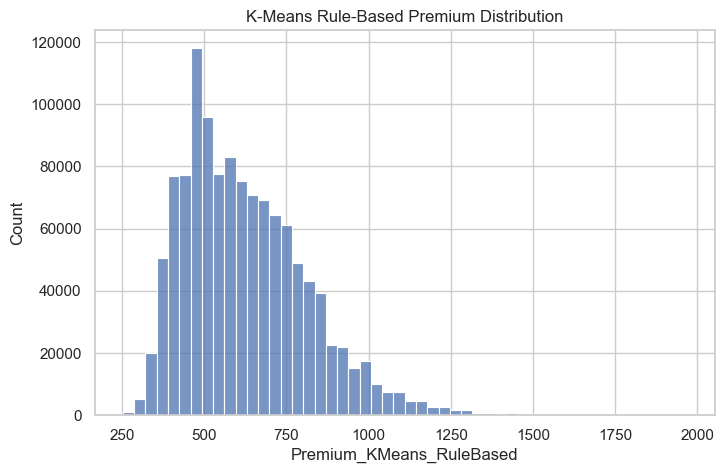

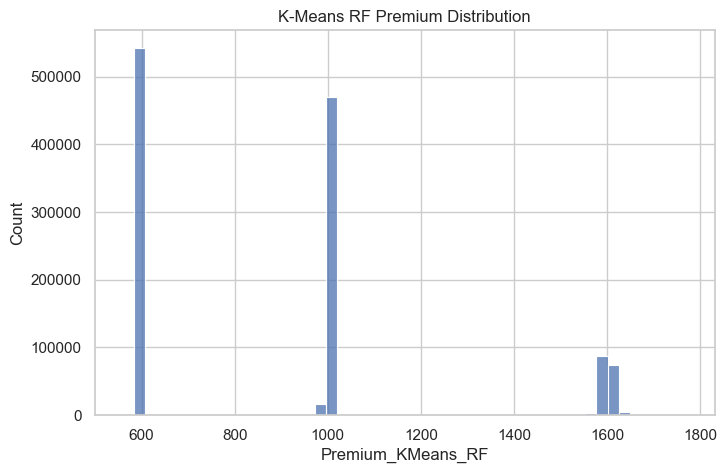

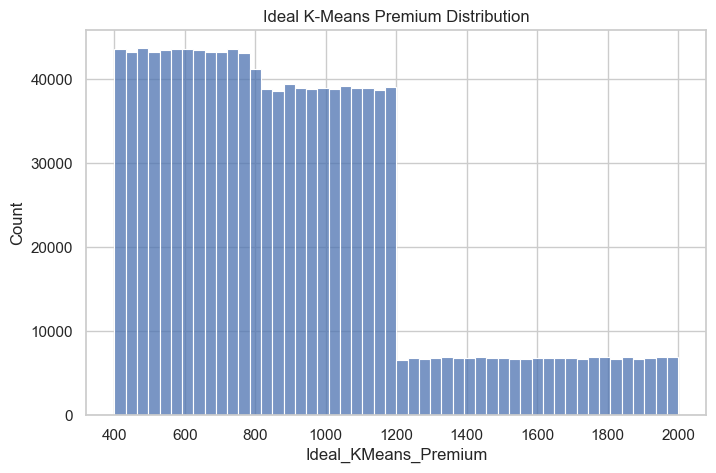

In [29]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Premium_KMeans_RuleBased"], bins=50)
plt.title("K-Means Rule-Based Premium Distribution")
plt.xlabel("Premium_KMeans_RuleBased")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df["Premium_KMeans_RF"], bins=50)
plt.title("K-Means RF Premium Distribution")
plt.xlabel("Premium_KMeans_RF")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df["Ideal_KMeans_Premium"], bins=50)
plt.title("Ideal K-Means Premium Distribution")
plt.xlabel("Ideal_KMeans_Premium")
plt.ylabel("Count")
plt.show()

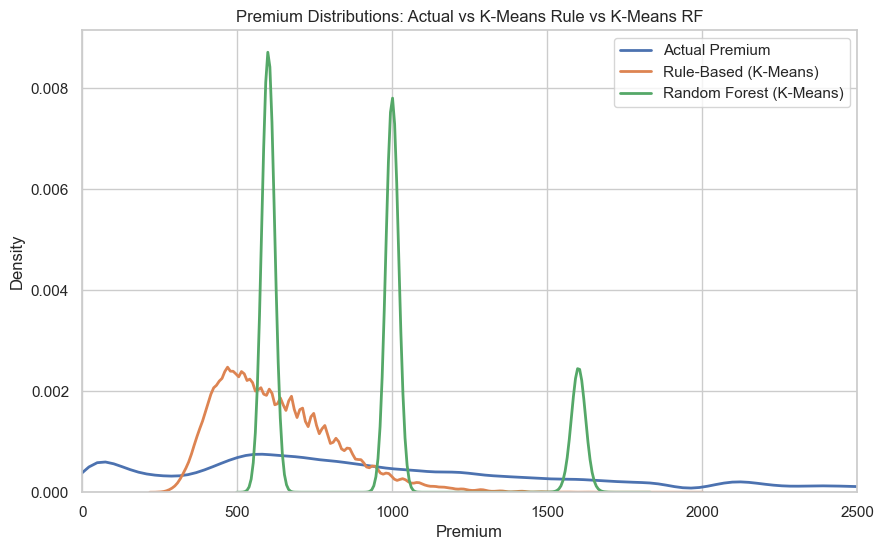

In [30]:
plt.figure(figsize=(10, 6))

sns.kdeplot(df["Premium Amount"], label="Actual Premium", linewidth=2)
sns.kdeplot(df["Premium_KMeans_RuleBased"], label="Rule-Based (K-Means)", linewidth=2)
sns.kdeplot(df["Premium_KMeans_RF"], label="Random Forest (K-Means)", linewidth=2)

plt.title("Premium Distributions: Actual vs K-Means Rule vs K-Means RF")
plt.xlabel("Premium")
plt.ylabel("Density")
plt.legend()
plt.xlim(0, 2500)
plt.show()

In [31]:
output_path = "../data/premium_kmeans_only.csv"
cols_to_save = [
    "Age",
    "Annual Income",
    "Health Score",
    "Credit Score",
    "Previous Claims",
    "Vehicle Age",
    "Smoking Status",
    "Premium Amount",
    "KMeans_Risk_Class",
    "KMeans_Risk_Label",
    "Premium_KMeans_RuleBased",
    "Ideal_KMeans_Premium",
    "Premium_KMeans_RF",
]

df[cols_to_save].to_csv(output_path, index=False)
print(f"\n[Step 10] Saved K-Means premium results to: {output_path}")


[Step 10] Saved K-Means premium results to: ../data/premium_kmeans_only.csv
